
### Detecting Insider Threats Using Behavioral Machine Learning
### MSc Dissertation – Modelling Notebook
### Author: Ein Gyin Moe




---



####1. Importing Libraries

In [1]:
# ======================================================
# Install libraries and import packages
# ======================================================
'''This project uses a combination of data handling, machine learning, deep learning, and visualization libraries to build an end-to-end insider-threat detection pipeline.'''

#Core and data manipulation
import pandas as pd #Data loading, cleaning, dataFrame
import numpy as np #Numerical operations, arrays, mathematical functions

#Virtualization
import matplotlib.pyplot as plt #Plotting basics (line charts, histograms, bar charts)
import seaborn as sns #advanced statistical plots with better styling

#ML Data preprocessing, splitting, model evaluation
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_validate, RandomizedSearchCV #Splitting dataset, cross-validation, and hyperparameter tuning
from sklearn.preprocessing import OneHotEncoder, StandardScaler #Scaling numeric features and encoding categorical features
from sklearn.compose import ColumnTransformer #Applies different preprocessing to numeric vs categorical columns
from sklearn.metrics import roc_curve, roc_auc_score #ROC curve generation
from sklearn.metrics import precision_recall_curve, average_precision_score # Precision–Recall curve analysis
from sklearn.pipeline import Pipeline #Combine preprocessing + model
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, classification_report,confusion_matrix) #evaluation matrix

# Traditional ML models
from sklearn.linear_model import LogisticRegression           # GLM baseline classifier (Logit)
from sklearn.naive_bayes import GaussianNB                    # NB classifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis  # FLM (LDA) model
from sklearn.tree import DecisionTreeClassifier               # DT
from sklearn.ensemble import RandomForestClassifier           # RF
from sklearn.svm import SVC                                   # SVM (RBF)
import joblib  # Save/load trained models efficiently

# Gradient boosting
from xgboost import XGBClassifier                             # GBT (XGBoost)

# Deep Learning
import tensorflow as tf #Deep learning backend
from tensorflow.keras import layers, models, callbacks #Build ANN layers & training utilities

#Explainability SHAP
!pip install shap #SHAP for model interpretability
import shap  # Explain feature contributions

#Setting
RANDOM_STATE = 42 #Reproducibility
sns.set(style="whitegrid") #Consistent plot style



---



#### 2. Load Cleaned Dataset

In [2]:
# ======================================================
# Load the cleaned insider threat dataset
# ======================================================
'''
This dataset is a balanced subset extracted from the larger insider-threat logs: 6,000 "Insider" cases and 6,000 "Normal" cases.
It has not yet had leakage fields removed — columns such as `event_src`, `date`, `user`, and `pc` will be dropped later during preprocessing.
This balanced sample makes modelling faster while keeping the class distribution equal for fair training.
'''
df = pd.read_csv("/content/drive/MyDrive/AppliedResearchProj_Dataset/Coding_Dataset/AppliedResearchDataset_cleanVer1.csv")
df.head()

,is_insider,id,user,pc,event_src,activity,date,to_removable_media,from_removable_media,size,Openness score,Conscientiousness score,Extraversion score,Agreeableness score,Neuroticism score
0,True,{T2N6-X9QL06RX-0762MGAR},CSC0217,PC-5391,logon,Logon,6/10/2010 0:00,False,False,0,40,15,30,38,28
1,True,{H5W6-B8OS58UZ-7808LFON},CSC0217,PC-6377,logon,Logon,6/11/2010 0:00,False,False,0,40,15,30,38,28
2,True,{J4H8-U4HY76KF-8654QSST},CSC0217,PC-6377,logon,Logon,6/11/2010 0:00,False,False,0,40,15,30,38,28
3,True,{K7J1-R9NA31CC-0202USEF},CSC0217,PC-5391,logon,Logoff,6/10/2010 0:00,False,False,0,40,15,30,38,28
4,True,{E6S3-A8MW97SQ-7179CYTE},CSC0217,PC-9873,logon,Logoff,6/10/2010 0:00,False,False,0,40,15,30,38,28




---



#### 3. Basic Data Understanding

In [3]:
# ======================================================
# Data Understanding and Structure Overview
# ======================================================
print("Shape:", df.shape) #Display first few row
print("\nFirst 5 rows:") #Preview first 5 rows (helps confirm data loaded correctly)
display(df.head())


Shape: (12000, 15)

First 5 rows:


,is_insider,id,user,pc,event_src,activity,date,to_removable_media,from_removable_media,size,Openness score,Conscientiousness score,Extraversion score,Agreeableness score,Neuroticism score
0,True,{T2N6-X9QL06RX-0762MGAR},CSC0217,PC-5391,logon,Logon,6/10/2010 0:00,False,False,0,40,15,30,38,28
1,True,{H5W6-B8OS58UZ-7808LFON},CSC0217,PC-6377,logon,Logon,6/11/2010 0:00,False,False,0,40,15,30,38,28
2,True,{J4H8-U4HY76KF-8654QSST},CSC0217,PC-6377,logon,Logon,6/11/2010 0:00,False,False,0,40,15,30,38,28
3,True,{K7J1-R9NA31CC-0202USEF},CSC0217,PC-5391,logon,Logoff,6/10/2010 0:00,False,False,0,40,15,30,38,28
4,True,{E6S3-A8MW97SQ-7179CYTE},CSC0217,PC-9873,logon,Logoff,6/10/2010 0:00,False,False,0,40,15,30,38,28


In [4]:
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns") #Confirm dataset dimensions again with explanation
print("\nData Types:") #Check data types (numeric vs categorical)
display(df.dtypes)


Dataset Shape: 12000 rows × 15 columns

Data Types:


,0
is_insider,bool
id,object
user,object
pc,object
event_src,object
activity,object
date,object
to_removable_media,bool
from_removable_media,bool
size,int64


In [5]:
print("\nSummary Statistics (Numeric):") #Summary stats for numeric columns (mean, std, range, etc.)
display(df.describe().T)


Summary Statistics (Numeric):


,count,mean,std,min,25%,50%,75%,max
size,12000.0,71.892083,1604.058211,0.0,0.0,0.0,0.0,54903.0
Openness score,12000.0,32.209500,12.187425,0.0,17.0,36.0,41.0,50.0
Conscientiousness score,12000.0,32.605667,10.089309,0.0,23.0,35.0,40.0,50.0
Extraversion score,12000.0,29.121833,10.588878,0.0,20.0,31.0,38.0,50.0
Agreeableness score,12000.0,29.070333,10.689695,0.0,20.0,28.0,39.0,50.0
Neuroticism score,12000.0,29.028833,4.791077,0.0,28.0,29.0,32.0,41.0


In [6]:
print("\nUnique Values in Categorical Columns:") # Check unique value counts for categorical features,Helps identify: low/high cardinality, encoding needs
for col in df.select_dtypes(include=["object", "category"]).columns:
    print(f"{col}: {df[col].nunique()} unique values")


Unique Values in Categorical Columns:
id: 6176 unique values
user: 194 unique values
pc: 355 unique values
event_src: 3 unique values
activity: 5 unique values
date: 232 unique values


In [7]:
print("\nMissing Values per Column:") #Check missing values to ensures no hidden nulls before preprocessing
display(df.isnull().sum())


Missing Values per Column:


,0
is_insider,0
id,0
user,0
pc,0
event_src,0
activity,0
date,0
to_removable_media,0
from_removable_media,0
size,0


In [8]:
print("\nTarget distribution (is_insider):") # Check target label distribution (is_insider) and confirms the dataset is balanced: 6000 insider / 6000 normal
print(df["is_insider"].value_counts())
print("\nTarget distribution (normalised):")
print(df["is_insider"].value_counts(normalize=True))


Target distribution (is_insider):
is_insider
True     6000
False    6000
Name: count, dtype: int64

Target distribution (normalised):
is_insider
True     0.5
False    0.5
Name: proportion, dtype: float64




---



#### 4. Class Balance Check

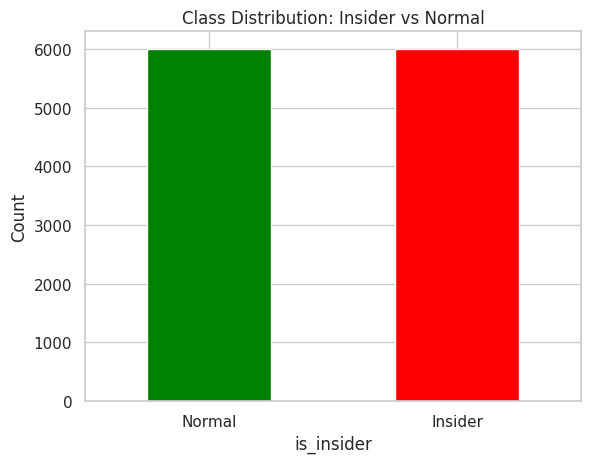

In [9]:
# ================================================
# Class Distribution (Normal vs Insider)
# ================================================
df["is_insider"].value_counts().plot(kind="bar", color=["green", "red"]) #Quick check to confirm the dataset is balanced.
# A balanced target helps prevent model bias.
plt.title("Class Distribution: Insider vs Normal")
plt.xticks([0,1], ["Normal", "Insider"], rotation=0)
plt.ylabel("Count")
plt.show()



---



#### 5. Exploratory Data Analysis (EDA)
Histograms

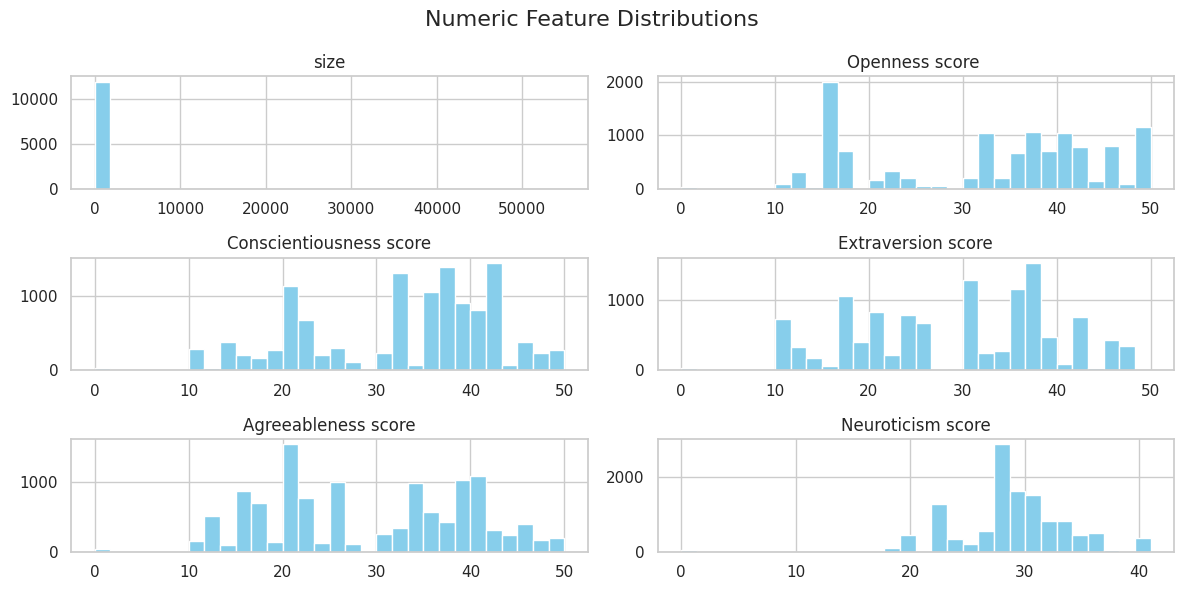

In [10]:
# ==============================================================
# Exploratory Data Analysis – Numeric Features (Histograms)
# ==============================================================
numeric_cols = [ "size", "Openness score ", "Conscientiousness score", "Extraversion score", "Agreeableness score", "Neuroticism score"] # Visualise distributions of numeric variables to understand ranges, outliers, and general behaviour before modelling.
df[numeric_cols].hist(figsize=(12, 6), bins=30, color="skyblue")
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

Bar Chart

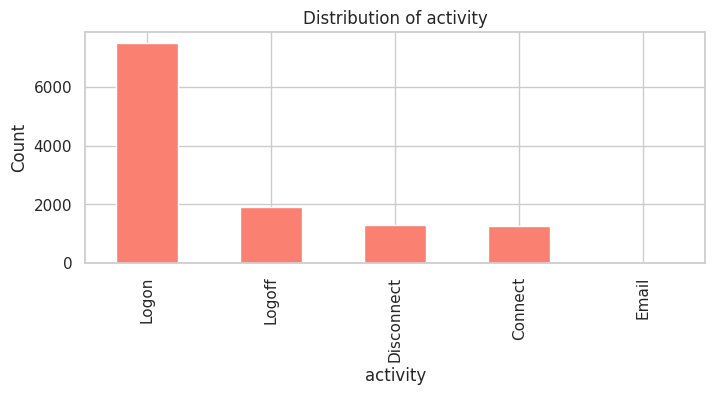

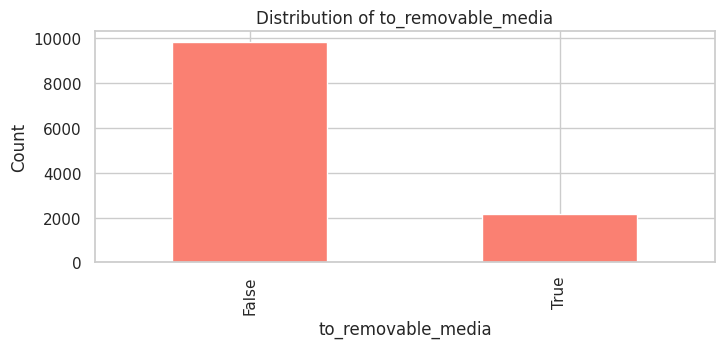

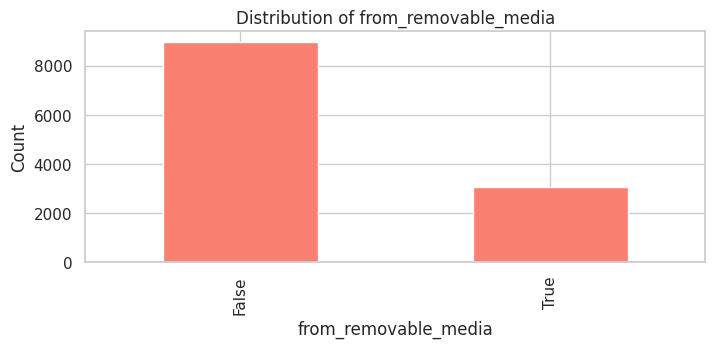

In [11]:
# ====================================================================
# Exploratory Data Analysis – Categorical Features (Bar Charts)
# ====================================================================
categorical_cols = [ "activity","to_removable_media","from_removable_media"] #Shows the frequency of each category to understand behavioural patterns in activities and removable-media events.
for col in categorical_cols:
    plt.figure(figsize=(8,3))
    df[col].value_counts().plot(kind="bar", color="salmon")
    plt.title(f"Distribution of {col}")
    plt.ylabel("Count")
    plt.show()

EDA – Correlation Heatmap (Numeric Features)


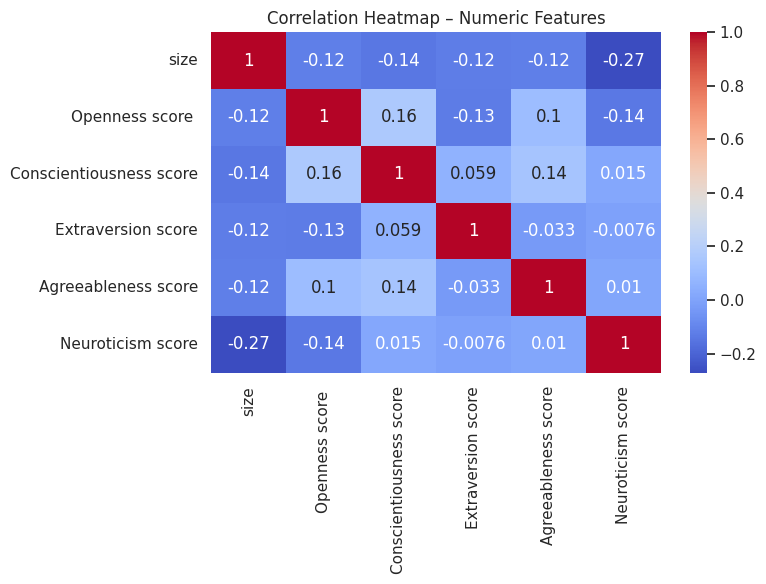

In [12]:
# ======================================================
# Correlation Heatmap – Numeric Features
# ======================================================
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap – Numeric Features")
plt.tight_layout()
plt.show()

Activity vs Label

Detected label column: is_insider


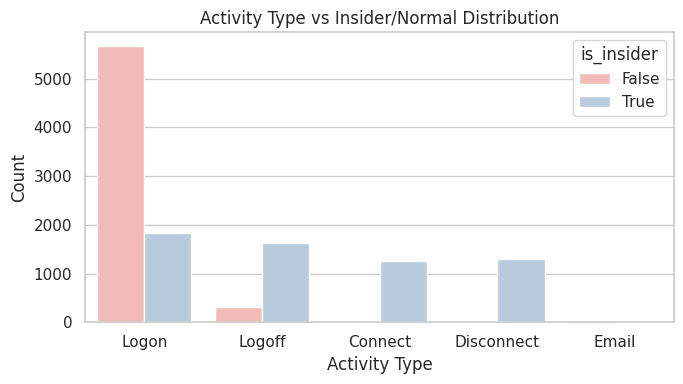

In [13]:
# ======================================================
# Behaviour vs Label Analysis (Activity Correlation)
# ======================================================
label_col = [col for col in df.columns if df[col].nunique() == 2][0]
print("Detected label column:", label_col)

# =================================
# # Activity vs Label
# =================================
plt.figure(figsize=(7,4))
sns.countplot(x="activity", hue=label_col, data=df, palette="Pastel1")
plt.title("Activity Type vs Insider/Normal Distribution")
plt.xlabel("Activity Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


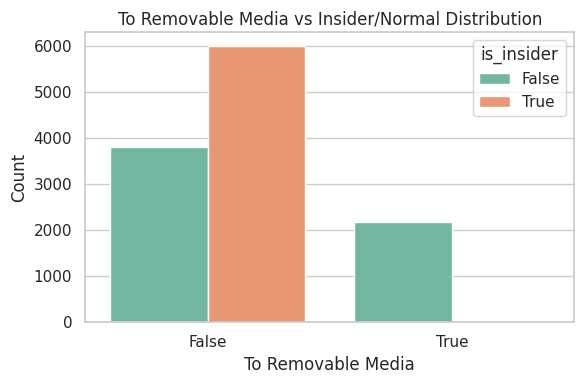

In [14]:
# =================================
# To Removable Media vs Label
# =================================
plt.figure(figsize=(6,4))
sns.countplot(x="to_removable_media", hue=label_col, data=df, palette="Set2")
plt.title("To Removable Media vs Insider/Normal Distribution")
plt.xlabel("To Removable Media")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


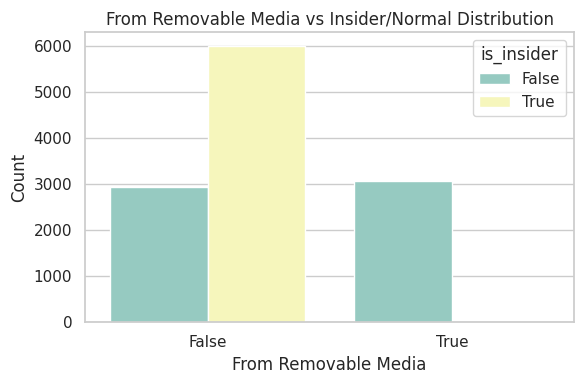

In [15]:
# =================================
# From Removable Media vs Label
# =================================
plt.figure(figsize=(6,4))
sns.countplot(x="from_removable_media", hue=label_col, data=df, palette="Set3")
plt.title("From Removable Media vs Insider/Normal Distribution")
plt.xlabel("From Removable Media")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 6. Preprocessing

In [16]:
# ======================================================================================
# Preprocessing Pipeline (Encoding + Scaling) (drop all leakage / identity columns)
# ======================================================================================
df["is_insider"] = df["is_insider"].astype(int) #Convert target to int
df_model = df.drop(columns=["id","event_src", "date", "user", "pc"]) #Drop: id -> row identifier, event_src  -> which monitoring system produced the log (leakage), date -> temporal leakage (insiders active in certain windows), user, pc    -> direct identity and machine identifiers

X = df_model.drop(columns=["is_insider"]) # Features (X) and label (y)
y = df_model["is_insider"]

numeric_features = ["size","Openness score ", "Conscientiousness score","Extraversion score","Agreeableness score","Neuroticism score"] # Numeric features (scaled)
categorical_features = [ "activity", "to_removable_media","from_removable_media"] # Categorical features (one-hot encoded)
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Numeric: ['size', 'Openness score ', 'Conscientiousness score', 'Extraversion score', 'Agreeableness score', 'Neuroticism score']
Categorical: ['activity', 'to_removable_media', 'from_removable_media']


In [17]:
# ===================================================================================================
# Build preprocessing pipeline (Standardise numeric features/One-hot encode categorical features)
# ===================================================================================================
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")
preprocessor = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features),("cat", categorical_transformer, categorical_features)])
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['size', 'Openness score ',
                                  'Conscientiousness score',
                                  'Extraversion score', 'Agreeableness score',
                                  'Neuroticism score']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['activity', 'to_removable_media',
                                  'from_removable_media'])])


#### 7. Train-Test Split

In [18]:
# ===================================
# Define X, y and feature groups
# ===================================
X_train, X_test, y_train, y_test = train_test_split( # Train/test split (80/20) with stratification to preserve class balance
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (9600, 9)  Test shape: (2400, 9)


#### 8. Evaluation Helper

In [19]:
# ==============================================================
# Shared Evaluation Function (Metrics + Confusion Matrix)
#    - computes metrics
#    - prints classification report
#    - plots confusion matrix with model-specific colour
#    - stores metrics in results dict
# ==============================================================

results = {}   # dictionary to store metrics

# Define a colour map per model for visual variety
cmaps = {
    "NB":           "Greys",
    "FLM (LDA)":    "Purples",
    "DT":           "Oranges",
    "GLM (Logit)":  "Blues",
    "RF":           "Greens",
    "SVM":          "PuRd",
    "GBT":          "YlGnBu",
    "DL":           "Reds"
}
def evaluate_and_store(name, y_true, y_pred, y_proba):
    """
    Evaluate a model on the test set and store performance metrics.

    Parameters
    ----------
    name : str
        Name of the model. Also used as a key in the global `results` dict.
    y_true : array-like
        True binary labels (0 = Normal, 1 = Insider).
    y_pred : array-like
        Predicted class labels from the model.
    y_proba : array-like
        Predicted probability scores for the positive class (Insider).

    This function:
    -------------
    - Computes Accuracy, Classification Error, ROC-AUC, Precision, Recall, and F1-score.
    - Prints a full classification report.
    - Plots a confusion matrix using a model-specific colour map.
    - Saves the metrics into the global `results` dictionary for final comparison.
    """

    # Compute metrics
    acc  = accuracy_score(y_true, y_pred)
    ce   = 1 - acc
    auc  = roc_auc_score(y_true, y_proba)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    # Print metrics summary
    print(f"\n{name} – Test Metrics")
    print(f"Accuracy           : {acc:.4f}")
    print(f"Classification Err.: {ce:.4f}")
    print(f"ROC-AUC            : {auc:.4f}")
    print(f"Precision          : {prec:.4f}")
    print(f"Recall             : {rec:.4f}")
    print(f"F1-score           : {f1:.4f}\n")
    print("Classification report:\n")
    print(
        classification_report(
            y_true, y_pred,target_names=["Normal (0)", "Insider (1)"])
    )

    # Confusion matrix with model-specific colour
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmaps.get(name, "Blues"),   # model-specific colour
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    # Save metrics in dictionary for comparison table
    results[name] = {
        "accuracy": acc,
        "classification_error": ce,
        "AUC": auc,
        "precision": prec,
        "recall": rec,
        "F1": f1
    }

#### 9. Baseline Models

In [20]:
# ======================================================
# Baseline Models (NB, LDA, DT, Logistic Regression)
# ======================================================
"""
Baseline models are implemented to provide simple, interpretable benchmarks
before moving into more complex machine learning methods. These models help
establish whether basic statistical approaches can separate Insider vs Normal
behaviour using behavioural and psychological features.

The baseline models evaluated here are:

1. Naive Bayes (NB)
   - Assumes independence between features.
   - Useful as a quick probabilistic baseline.

2. Fisher Linear Discriminant Analysis (LDA / FLM)
   - Linear classifier that maximises class separation.
   - Good for linearly separable behavioural data.

3. Decision Tree (DT)
   - Simple non-linear model that splits on features.
   - Helps reveal simple decision rules.

4. Logistic Regression (GLM – Logit)
   - Linear but probabilistic classifier.
   - Often strong on structured tabular data.

These baselines help determine whether more advanced models (RF, SVM, XGBoost, DL)
are necessary, and provide a reference point for comparison.
"""

'\nBaseline models are implemented to provide simple, interpretable benchmarks\nbefore moving into more complex machine learning methods. These models help\nestablish whether basic statistical approaches can separate Insider vs Normal\nbehaviour using behavioural and psychological features.\n\nThe baseline models evaluated here are:\n\n1. Naive Bayes (NB)\n   - Assumes independence between features.\n   - Useful as a quick probabilistic baseline.\n\n2. Fisher Linear Discriminant Analysis (LDA / FLM)\n   - Linear classifier that maximises class separation.\n   - Good for linearly separable behavioural data.\n\n3. Decision Tree (DT)\n   - Simple non-linear model that splits on features.\n   - Helps reveal simple decision rules.\n\n4. Logistic Regression (GLM – Logit)\n   - Linear but probabilistic classifier.\n   - Often strong on structured tabular data.\n\nThese baselines help determine whether more advanced models (RF, SVM, XGBoost, DL)\nare necessary, and provide a reference point fo


NB – Test Metrics
Accuracy           : 0.9396
Classification Err.: 0.0604
ROC-AUC            : 0.9396
Precision          : 0.8922
Recall             : 1.0000
F1-score           : 0.9430

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.88      0.94      1200
 Insider (1)       0.89      1.00      0.94      1200

    accuracy                           0.94      2400
   macro avg       0.95      0.94      0.94      2400
weighted avg       0.95      0.94      0.94      2400



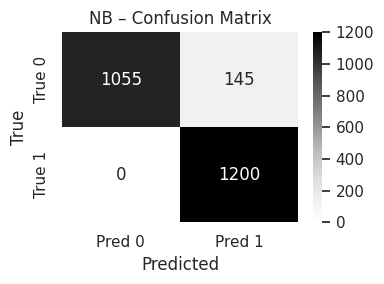

In [21]:
# ===============================
# Naive Bayes (NB)
# ===============================

nb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

nb_clf.fit(X_train, y_train)
y_pred_nb  = nb_clf.predict(X_test)
y_proba_nb = nb_clf.predict_proba(X_test)[:, 1]
evaluate_and_store("NB", y_test, y_pred_nb, y_proba_nb)


FLM (LDA) – Test Metrics
Accuracy           : 0.9396
Classification Err.: 0.0604
ROC-AUC            : 0.9907
Precision          : 0.8922
Recall             : 1.0000
F1-score           : 0.9430

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.88      0.94      1200
 Insider (1)       0.89      1.00      0.94      1200

    accuracy                           0.94      2400
   macro avg       0.95      0.94      0.94      2400
weighted avg       0.95      0.94      0.94      2400



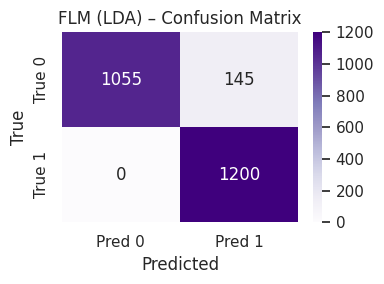

In [22]:
# ======================================================
# Fisher Linear Model (FLM) – Linear Discriminant Analysis
# Linear boundary, good as "flat" baseline
# ======================================================
lda_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearDiscriminantAnalysis())
])

lda_clf.fit(X_train, y_train)
y_pred_lda  = lda_clf.predict(X_test)
y_proba_lda = lda_clf.predict_proba(X_test)[:, 1]
evaluate_and_store("FLM (LDA)", y_test, y_pred_lda, y_proba_lda)



DT – Test Metrics
Accuracy           : 0.9983
Classification Err.: 0.0017
ROC-AUC            : 0.9983
Precision          : 0.9967
Recall             : 1.0000
F1-score           : 0.9983

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00      1200
 Insider (1)       1.00      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



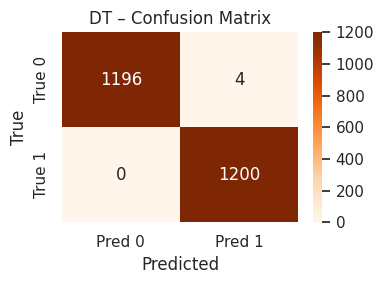

In [23]:
# ======================================================
# Decision Tree (DT)
# Single tree, interpretable rules
# ======================================================

dt_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=None,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

dt_clf.fit(X_train, y_train)

y_pred_dt  = dt_clf.predict(X_test)
y_proba_dt = dt_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("DT", y_test, y_pred_dt, y_proba_dt)



GLM (Logit) – Test Metrics
Accuracy           : 0.9546
Classification Err.: 0.0454
ROC-AUC            : 0.9911
Precision          : 0.9389
Recall             : 0.9725
F1-score           : 0.9554

Classification report:

              precision    recall  f1-score   support

  Normal (0)       0.97      0.94      0.95      1200
 Insider (1)       0.94      0.97      0.96      1200

    accuracy                           0.95      2400
   macro avg       0.96      0.95      0.95      2400
weighted avg       0.96      0.95      0.95      2400



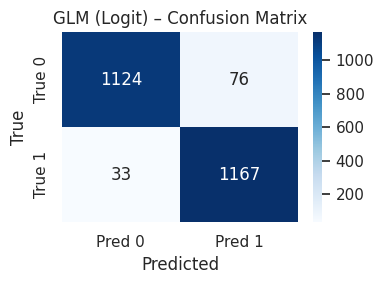

['insider_glm_logit.pkl']

In [24]:
# ======================================================
# Generalised Linear Model (GLM – Logistic Regression)
# Logit link, baseline linear classifier
# ======================================================

glm_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

glm_clf.fit(X_train, y_train)

y_pred_glm  = glm_clf.predict(X_test)
y_proba_glm = glm_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("GLM (Logit)", y_test, y_pred_glm, y_proba_glm)

# Save GLM model
joblib.dump(glm_clf, "insider_glm_logit.pkl")


#### 10. Deep Learning Model


In [25]:
# ============================================================
#  Deep Learning model (DL – Feed-forward Neural Network)
# ============================================================

preprocessor_dl = preprocessor.fit(X_train) # Fit preprocessor on training data only (to avoid peeking at test)
X_train_dl = preprocessor_dl.transform(X_train)
X_test_dl  = preprocessor_dl.transform(X_test)

if hasattr(X_train_dl, "toarray"): # Convert sparse matrix (from OneHotEncoder) to dense for Keras
    X_train_dl = X_train_dl.toarray()
    X_test_dl  = X_test_dl.toarray()
input_dim = X_train_dl.shape[1]

model_dl = models.Sequential([ # Define simple fully-connected network
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"), #relu in hidden layers, helps the model learn non-linear patterns.
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")   #sigmoid in output layer for binary classificartion.
])

model_dl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


es = callbacks.EarlyStopping( # Early stopping to avoid overfitting, to stop training when validation loss stops improving
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model_dl.fit(
    X_train_dl, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8029 - loss: 0.4456 - val_accuracy: 0.9474 - val_loss: 0.1056
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9583 - loss: 0.1110 - val_accuracy: 0.9682 - val_loss: 0.0815
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9637 - loss: 0.0968 - val_accuracy: 0.9734 - val_loss: 0.0721
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9711 - loss: 0.0756 - val_accuracy: 0.9786 - val_loss: 0.0666
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9707 - loss: 0.0780 - val_accuracy: 0.9745 - val_loss: 0.0627
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9765 - loss: 0.0743 - val_accuracy: 0.9786 - val_loss: 0.0578
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9824 - loss: 0.0541 - val_accuracy: 0.9786 - val_loss: 0.0545
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9813 - loss: 0.0592 - val_accura

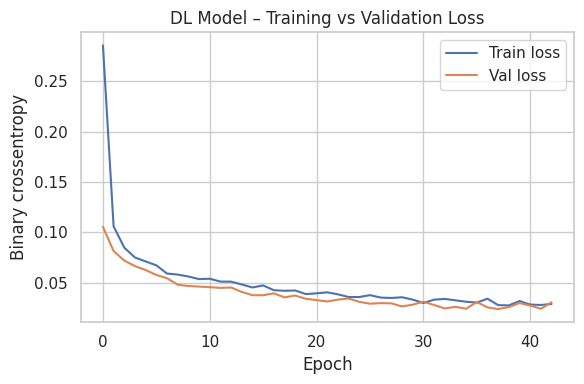

In [26]:
# ======================================================
# DL Model – Training vs Validation Loss
# ======================================================
# Training history plot for DL
hist = history.history
plt.figure(figsize=(6,4))
plt.plot(hist["loss"], label="Train loss")
plt.plot(hist["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Binary crossentropy")
plt.title("DL Model – Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


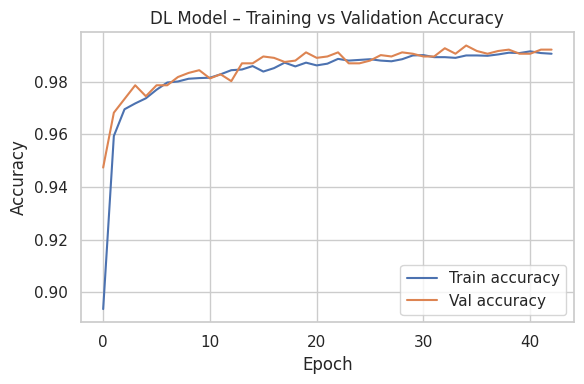

In [27]:
# ======================================================
# DL Model – Training vs Validation Accuracy Curve
# ======================================================
plt.figure(figsize=(6,4))
plt.plot(hist["accuracy"], label="Train accuracy")
plt.plot(hist["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DL Model – Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

DL – Test Metrics
Accuracy           : 0.9925
Classification Err.: 0.0075
ROC-AUC            : 0.9989
Precision          : 0.9868
Recall             : 0.9983
F1-score           : 0.9925

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      0.99      1200
 Insider (1)       0.99      1.00      0.99      1200

    accuracy                           0.99      2400
   macro avg       0.99      0.99      0.99      2400
weighted avg       0.99      0.99      0.99      2400



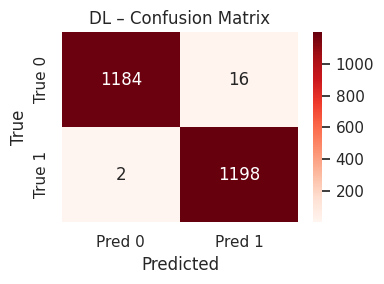

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,109 (121.52 KB)

 Trainable params: 10,369 (40.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,740 (81.02 KB)

In [28]:

# Evaluate on test set
y_proba_dl = model_dl.predict(X_test_dl).ravel()
y_pred_dl  = (y_proba_dl >= 0.5).astype(int)
evaluate_and_store("DL", y_test, y_pred_dl, y_proba_dl)

# Save DL model (new Keras recommended format)
model_dl.save("insider_deep_nn.keras")

# Save preprocessor
joblib.dump(preprocessor_dl, "insider_preprocessor_for_dl.pkl")

# ===========================================
# Deep Learning Architecture Summary
# ===========================================
model_dl.summary()

#### 11. Advanced Machine Learning Models ( Random Forest, SVM, XGBoost)

In [29]:
# ======================================================
# Advanced ML Models (SVM, Random Forest, XGBoost)
# ======================================================

"""
This section implements three advanced machine learning models that go beyond
the capabilities of basic linear classifiers. These models capture complex
non-linear relationships found in behavioural and psychological insider-threat
patterns.

1. Support Vector Machine (SVM – RBF Kernel)
   - Effective for high-dimensional behavioural data.
   - Uses a radial basis function kernel to capture non-linear boundaries.
   - Useful when insider behaviour differs subtly from normal users.

2. Random Forest (RF)
   - Ensemble of decision trees that improves stability and robustness.
   - Handles mixed feature types well and reduces overfitting.
   - Provides feature importance for interpretability.

3. Gradient Boosted Trees (XGBoost)
   - One of the strongest models for structured/tabular data.
   - Learns patterns iteratively and handles complex interactions.
   - Provides high performance and detailed feature importance.

These models form the core of the experimental comparison, allowing us to
evaluate how simple, linear, and highly non-linear models perform on insider
behaviour prediction.
"""


'\nThis section implements three advanced machine learning models that go beyond\nthe capabilities of basic linear classifiers. These models capture complex\nnon-linear relationships found in behavioural and psychological insider-threat\npatterns.\n\n1. Support Vector Machine (SVM – RBF Kernel)\n   - Effective for high-dimensional behavioural data.\n   - Uses a radial basis function kernel to capture non-linear boundaries.\n   - Useful when insider behaviour differs subtly from normal users.\n\n2. Random Forest (RF)\n   - Ensemble of decision trees that improves stability and robustness.\n   - Handles mixed feature types well and reduces overfitting.\n   - Provides feature importance for interpretability.\n\n3. Gradient Boosted Trees (XGBoost)\n   - One of the strongest models for structured/tabular data.\n   - Learns patterns iteratively and handles complex interactions.\n   - Provides high performance and detailed feature importance.\n\nThese models form the core of the experimental 


RF – Test Metrics
Accuracy           : 0.9967
Classification Err.: 0.0033
ROC-AUC            : 1.0000
Precision          : 0.9934
Recall             : 1.0000
F1-score           : 0.9967

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



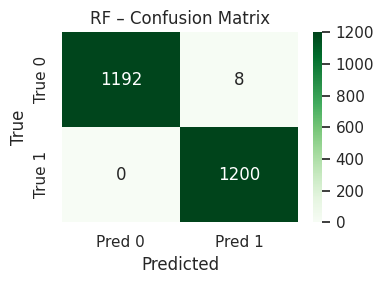

['insider_random_forest.pkl']

In [30]:
# ======================================================
# Random Forest (RF)
# Ensemble of decision trees
# ======================================================

rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)

y_pred_rf  = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("RF", y_test, y_pred_rf, y_proba_rf)

joblib.dump(rf_clf, "insider_random_forest.pkl")



SVM – Test Metrics
Accuracy           : 0.9846
Classification Err.: 0.0154
ROC-AUC            : 0.9964
Precision          : 0.9724
Recall             : 0.9975
F1-score           : 0.9848

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.97      0.98      1200
 Insider (1)       0.97      1.00      0.98      1200

    accuracy                           0.98      2400
   macro avg       0.98      0.98      0.98      2400
weighted avg       0.98      0.98      0.98      2400



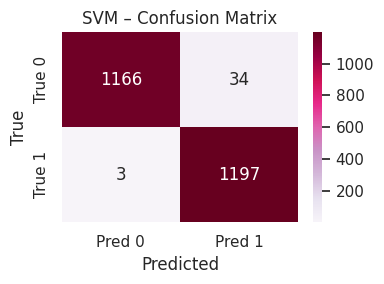

In [31]:
# ======================================================
# SVM with RBF kernel
# Non-linear margin-based classifier
# ======================================================

svm_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        probability=True,           # needed for ROC-AUC
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

svm_clf.fit(X_train, y_train)

y_pred_svm  = svm_clf.predict(X_test)
y_proba_svm = svm_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("SVM", y_test, y_pred_svm, y_proba_svm)



GBT – Test Metrics
Accuracy           : 0.9967
Classification Err.: 0.0033
ROC-AUC            : 1.0000
Precision          : 0.9934
Recall             : 1.0000
F1-score           : 0.9967

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



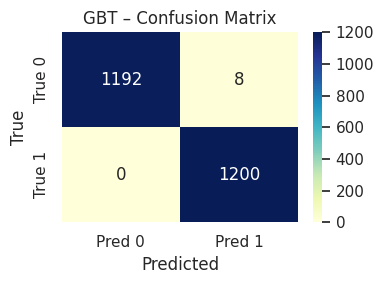

In [32]:
# ======================================================
# Gradient Boosted Trees (GBT – XGBoost)
# ======================================================

xgb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_clf.fit(X_train, y_train)

y_pred_xgb  = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("GBT", y_test, y_pred_xgb, y_proba_xgb)


#### 12. K-Fold Cross-Validation

In [33]:
# ======================================================
# K-Fold Cross-Validation (5-Fold)
# ======================================================

#5-fold stratified CV on the training set only for the main models: GLM (Logit), Random Forest, SVM, XGBoost (GBT)
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

# Models to include in CV
models_for_cv = {"GLM (Logit)": glm_clf,"RF": rf_clf,"SVM": svm_clf,"GBT": xgb_clf}

# Multiple metrics for each fold
scoring = {"accuracy": "accuracy","precision": "precision","recall": "recall","f1": "f1","roc_auc": "roc_auc"}

cv_results = {}
for name, model in models_for_cv.items():
    print(f"\nRunning 5-fold CV for: {name}")
    scores = cross_validate(model,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1,return_train_score=False)

    # Store mean and std for each metric
    summary = {
        f"{metric}_mean":  scores[f"test_{metric}"].mean()
        for metric in scoring.keys()
    }
    summary.update({
        f"{metric}_std":   scores[f"test_{metric}"].std()
        for metric in scoring.keys()
    })

    cv_results[name] = summary

# Put into a nice table
cv_df = pd.DataFrame(cv_results).T
cv_df = cv_df.round(4)

print("\nCross-Validation Results (5-fold, training set):")
display(cv_df)



Running 5-fold CV for: GLM (Logit)

Running 5-fold CV for: RF

Running 5-fold CV for: SVM

Running 5-fold CV for: GBT

Cross-Validation Results (5-fold, training set):


,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
GLM (Logit),0.9507,0.9374,0.9660,0.9515,0.9902,0.0023,0.0057,0.0054,0.0023,0.0005
RF,0.9973,0.9948,0.9998,0.9973,1.0000,0.0008,0.0015,0.0004,0.0008,0.0000
SVM,0.9794,0.9704,0.9890,0.9796,0.9955,0.0048,0.0066,0.0041,0.0047,0.0017
GBT,0.9978,0.9959,0.9998,0.9978,0.9998,0.0012,0.0024,0.0004,0.0012,0.0002


#### 13. Hyperparameter Tuning for RF and XGB

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF parameters: {'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 20}
Best RF CV ROC-AUC: 0.9999913194444444

RF (tuned) – Test Metrics
Accuracy           : 0.9967
Classification Err.: 0.0033
ROC-AUC            : 1.0000
Precision          : 0.9934
Recall             : 1.0000
F1-score           : 0.9967

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



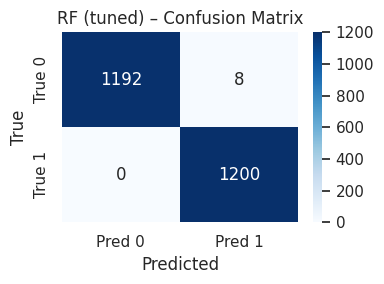

['insider_rf_tuned.pkl']

In [34]:
# ==============================================================================
# HYPERPARAMETER TUNING – Random Forest – Random Forest (RandomSearchCV)
# ==============================================================================

rf_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 400], #number of trees in the forest
    "model__max_depth": [5, 10, 20], #maximum depth of each tree (controls model complexity)
    "model__min_samples_split": [2, 5, 10], #minimum samples required to split an internal node
    "model__min_samples_leaf": [1, 2, 4] #minimum samples required at a leaf node
}

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best RF parameters:", rf_search.best_params_)
print("Best RF CV ROC-AUC:", rf_search.best_score_)

rf_best = rf_search.best_estimator_

y_pred_rf_tuned  = rf_best.predict(X_test)
y_proba_rf_tuned = rf_best.predict_proba(X_test)[:, 1]

evaluate_and_store("RF (tuned)", y_test, y_pred_rf_tuned, y_proba_rf_tuned)
joblib.dump(rf_best, "insider_rf_tuned.pkl")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.3, 'model__colsample_bytree': 1.0}
Best XGB CV ROC-AUC: 0.9998283420138889

GBT (tuned) – Test Metrics
Accuracy           : 0.9967
Classification Err.: 0.0033
ROC-AUC            : 0.9997
Precision          : 0.9934
Recall             : 1.0000
F1-score           : 0.9967

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



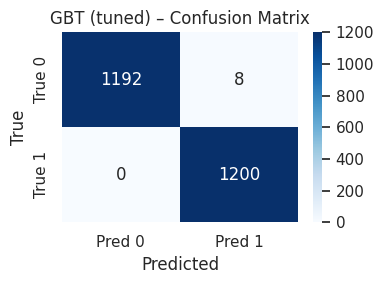

['insider_xgb_tuned.pkl']

In [35]:
# ==============================================================================
# Hyperparameter search space for XGBoost - (RandomSearchCV)
# ==============================================================================

xgb_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])


xgb_param_dist = {
    "model__n_estimators": [200, 300, 400], # Number of boosting trees (more trees = more capacity, but slower)
    "model__max_depth": [3, 5, 7], #Maximum depth of each tree (controls model complexity / overfitting)
    "model__learning_rate": [0.01, 0.05, 0.1],  # Learning rate / step size for each boosting iteration
    "model__subsample": [0.7, 0.8, 1.0],  # Subsample ratio for training rows (stochasticity + regularisation)
    "model__colsample_bytree": [0.7, 0.8, 1.0],  # Subsample ratio for features at each split (column sampling)
    "model__min_child_weight": [1, 3, 5],    # Minimum sum of instance weights (or sample count) in a child node; larger values make the model more conservative.
    "model__gamma": [0, 0.1, 0.3]     # Minimum loss reduction required to make a further split; larger gamma = fewer splits = stronger regularisation.
}

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best XGB parameters:", xgb_search.best_params_)
print("Best XGB CV ROC-AUC:", xgb_search.best_score_)

xgb_best = xgb_search.best_estimator_

y_pred_xgb_tuned  = xgb_best.predict(X_test)
y_proba_xgb_tuned = xgb_best.predict_proba(X_test)[:, 1]

evaluate_and_store("GBT (tuned)", y_test, y_pred_xgb_tuned, y_proba_xgb_tuned)
joblib.dump(xgb_best, "insider_xgb_tuned.pkl")


In [36]:
# ===========================================
# Random Forest tree stats
# ===========================================
rf_model = rf_best.named_steps["model"]
print("Random Forest n_estimators:", rf_model.n_estimators)
print("Random Forest max_depth:", rf_model.max_depth)

# XGBoost tree stats
xgb_model = xgb_best.named_steps["model"]
print("XGB n_estimators:", xgb_model.n_estimators)
print("XGB max_depth:", xgb_model.max_depth)


Random Forest n_estimators: 400
Random Forest max_depth: 20
XGB n_estimators: 200
XGB max_depth: 5


In [37]:
# ===========================================
# Hyperparameter Tuning Summary (RF + GBT)
# ===========================================

print("Best RF parameters:\n", rf_search.best_params_)
print("\nBest XGB parameters:\n", xgb_search.best_params_)


Best RF parameters:
 {'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 20}

Best XGB parameters:
 {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.3, 'model__colsample_bytree': 1.0}


#### 14. ROC Curves

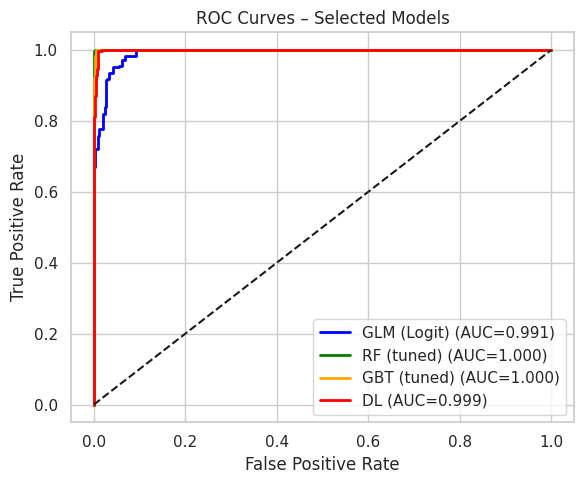

In [38]:
# ======================================================
# ROC Curves for Selected Models (GLM, RF, GBT, DL)
# ======================================================

# Collect true labels and probabilities for main models
roc_colors = {
    "GLM (Logit)": "blue",
    "RF (tuned)": "green",
    "GBT (tuned)": "orange",
    "DL": "red"
}

roc_models = {"GLM (Logit)": y_proba_glm,"RF (tuned)": y_proba_rf_tuned,"GBT (tuned)": y_proba_xgb_tuned,"DL": y_proba_dl}
plt.figure(figsize=(6,5))
for name, y_proba in roc_models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr,
             label=f"{name} (AUC={auc:.3f})",
             color=roc_colors[name],
             linewidth=2)

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Selected Models")
plt.legend()
plt.tight_layout()
plt.show()

#### 15. Precision–Recall Curves

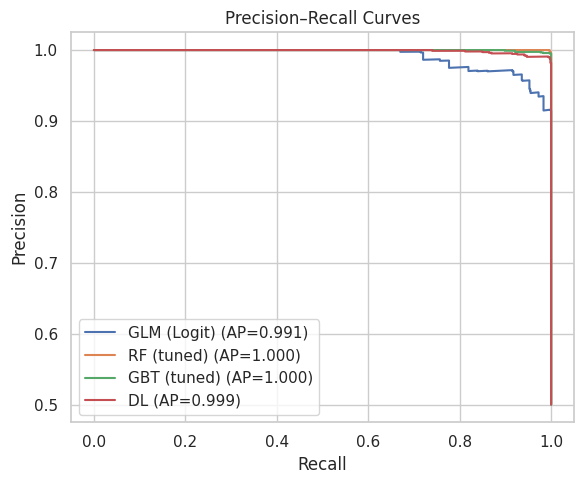

In [39]:
# ======================================================
# Precision–Recall Curves for  Key Models
# ======================================================


plt.figure(figsize=(6,5))

for name, y_proba in roc_models.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()


#### 16. Threshold Sensitivity Analysis


In [40]:
# ======================================================
# Threshold Sensitivity Analysis (Security Trade-offs)
# ======================================================
'''
The default threshold for predicting "Insider" is 0.50.
In security settings, lowering or raising the threshold can change how many threats are detected vs how many false alarms occur.
This section evaluates how model performance changes at thresholds 0.30, 0.50, and 0.70.
'''
def print_metrics_at_threshold(y_true, y_proba, thresh):
    y_pred_thresh = (y_proba >= thresh).astype(int)
    print(f"\n--- Threshold = {thresh:.2f} ---")
    print("Precision:", precision_score(y_true, y_pred_thresh))
    print("Recall   :", recall_score(y_true, y_pred_thresh))
    print("F1-score :", f1_score(y_true, y_pred_thresh))

thresholds_to_test = [0.30, 0.50, 0.70]
for t in thresholds_to_test:
    print_metrics_at_threshold(y_test, y_proba_xgb_tuned, t)



--- Threshold = 0.30 ---
Precision: 0.9900990099009901
Recall   : 1.0
F1-score : 0.9950248756218906

--- Threshold = 0.50 ---
Precision: 0.9933774834437086
Recall   : 1.0
F1-score : 0.9966777408637874

--- Threshold = 0.70 ---
Precision: 0.9950248756218906
Recall   : 1.0
F1-score : 0.9975062344139651


#### 17. Error Analysis

Number of misclassifications: 8

Misclassifications by activity:
activity
Logon    8
Name: count, dtype: int64


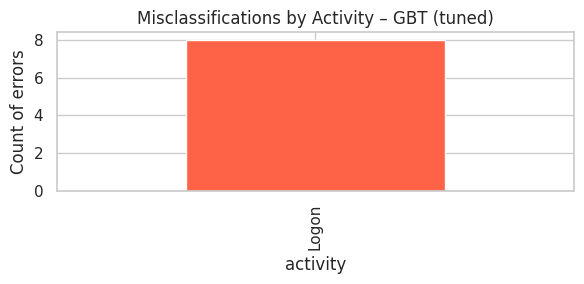

In [41]:
# ======================================================
# Error Analysis – Misclassifications by Activity Type
# ======================================================

# Get predictions at default threshold 0.5
y_pred_best = (y_proba_xgb_tuned >= 0.5).astype(int)

# Attach to a copy of test set with the original activity column
test_with_preds = X_test.copy()
test_with_preds["true_label"] = y_test.values
test_with_preds["pred_label"] = y_pred_best

# Misclassified rows only
errors = test_with_preds[test_with_preds["true_label"] != test_with_preds["pred_label"]]

print("Number of misclassifications:", len(errors))

# Count errors by activity type
err_by_activity = errors["activity"].value_counts()
print("\nMisclassifications by activity:")
print(err_by_activity)

plt.figure(figsize=(6, 3))
err_by_activity.plot(kind="bar", color="tomato")
plt.title("Misclassifications by Activity – GBT (tuned)")
plt.ylabel("Count of errors")
plt.tight_layout()
plt.show()


#### 18. Feature Importance (RF, XGB, GLM)

In [44]:
# ====================================================================================================
# Build transformed feature matrix & feature names (used for feature importance + SHAP)
# ====================================================================================================
# Use the same preprocessor that is in the pipelines to transform X_train and X_test to the encoded feature space.
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

# Build feature names: numeric + one-hot encoded categoricals.
# NOTE: this assumes you used "cat" for the categorical transformer and stored the categorical list in `categorical_features` and numeric list in `numeric_features`.
ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_feature_names

# Helper: convert sparse matrix to dense (needed for some SHAP explainers)
def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X

X_train_dense = to_dense(X_train_transformed)
X_test_dense  = to_dense(X_test_transformed)
print(f"Transformed train shape: {X_train_transformed.shape}")
print(f"Transformed test shape : {X_test_transformed.shape}")
print(f"Number of features     : {len(all_feature_names)}")


Transformed train shape: (9600, 15)
Transformed test shape : (2400, 15)
Number of features     : 15


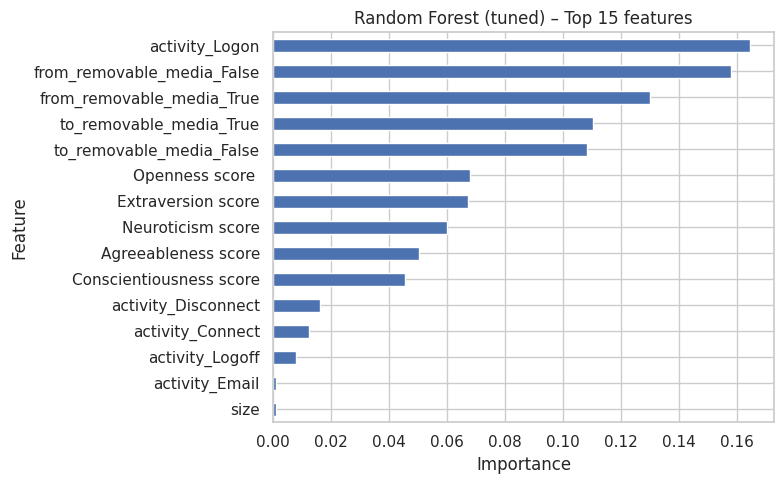

In [45]:
# ======================================================
# Feature importance – Random Forest (tuned)
# ======================================================
# What this does:
# - Extracts the tuned RF model from the pipeline
# - Reads its built-in feature_importances_
# - Shows the top 15 features in a horizontal bar chart

rf_model_only = rf_best.named_steps["model"]

rf_importances = pd.Series(
    rf_model_only.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

top_n = 15
plt.figure(figsize=(8,5))
rf_importances.head(top_n).iloc[::-1].plot(kind="barh")
plt.title(f"Random Forest (tuned) – Top {top_n} features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


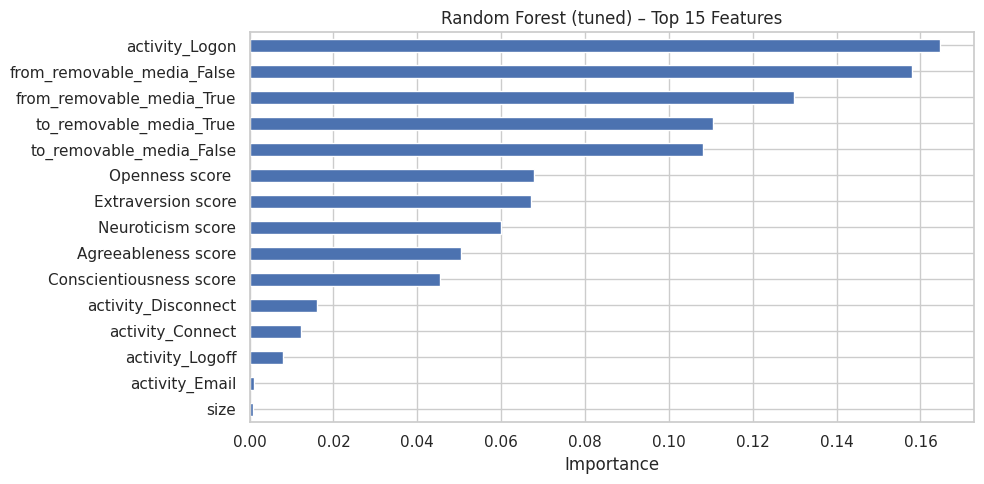

In [46]:
# ======================================================
# Feature Importance (Bar Charts)
# Random Forest (tuned), XGBoost (tuned), Logistic Regression (GLM)
# ======================================================
rf_model_only = rf_best.named_steps["model"] # Extract the tuned RF model from the pipeline

# RF has built-in feature_importances_
rf_importances = pd.Series(
    rf_model_only.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)
plt.figure(figsize=(10,5))
rf_importances.head(15).iloc[::-1].plot(kind="barh")
plt.title("Random Forest (tuned) – Top 15 Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

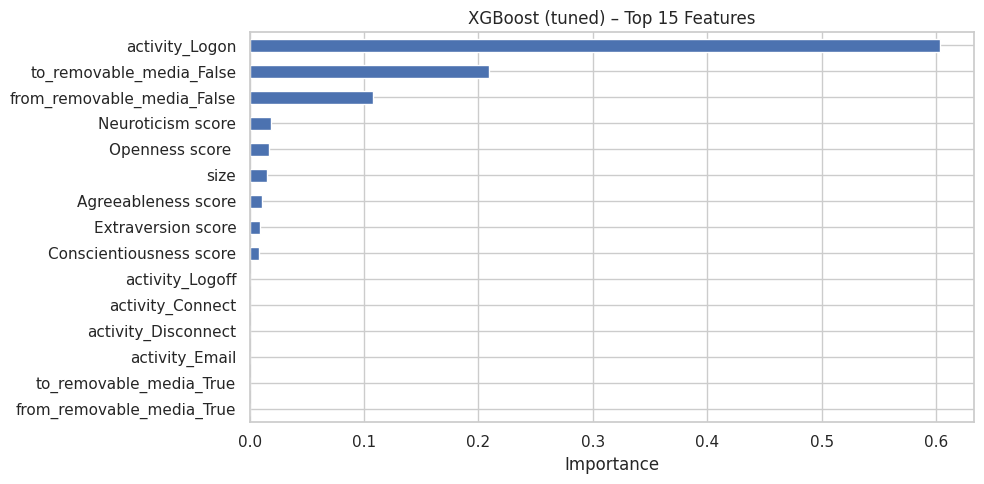

In [47]:
#XGBoost (tuned) feature importance
xgb_model_only = xgb_best.named_steps["model"]
xgb_importances = pd.Series(
    xgb_model_only.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)
plt.figure(figsize=(10,5))
xgb_importances.head(15).iloc[::-1].plot(kind="barh")
plt.title("XGBoost (tuned) – Top 15 Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

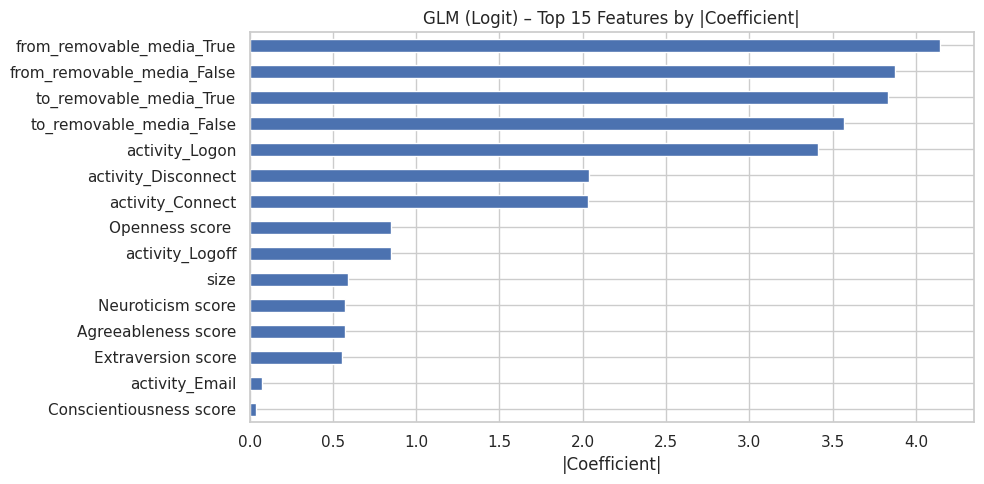

In [48]:
#Logistic Regression (GLM) "importance" via coefficients. For GLM, it use the absolute value of coefficients as a proxy for feature importance. Bigger |coef| = stronger effect.
glm_model_only = glm_clf.named_steps["model"]
glm_coefs = pd.Series(
    glm_model_only.coef_.ravel(),
    index=all_feature_names
).abs().sort_values(ascending=False)
plt.figure(figsize=(10,5))
glm_coefs.head(15).iloc[::-1].plot(kind="barh")
plt.title("GLM (Logit) – Top 15 Features by |Coefficient|")
plt.xlabel("|Coefficient|")
plt.tight_layout()
plt.show()

#### 19. SHAP Interpretability (RF, XGB, GLM)

In [49]:
# ==========================================================================================================
# SHAP Global Interpretability - XGBoost (tuned), Random Forest (tuned), Logistic Regression (GLM)
# ==========================================================================================================
shap.initjs() # Optional: nicer JS plots in some environments

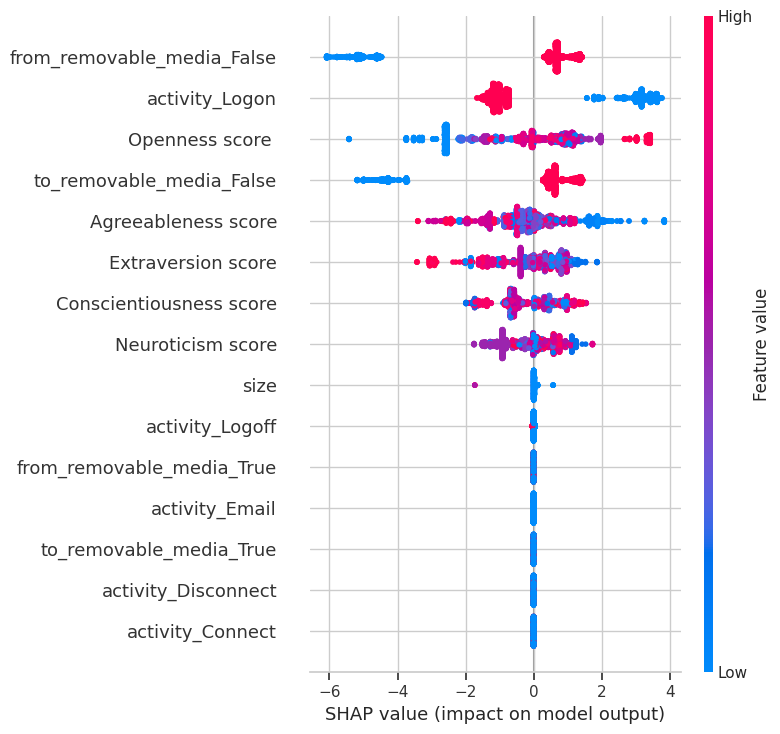

In [50]:
# ====================================
# SHAP summary – XGBoost (tuned)
# ====================================
xgb_model_only = xgb_best.named_steps["model"]
explainer_xgb = shap.TreeExplainer(xgb_model_only)
shap_values_xgb = explainer_xgb.shap_values(X_test_dense)
shap.summary_plot(shap_values_xgb,X_test_dense,feature_names=all_feature_names) # To explains how each feature pushes predictions towards "Insider" vs "Normal" for the tuned XGBoost model.


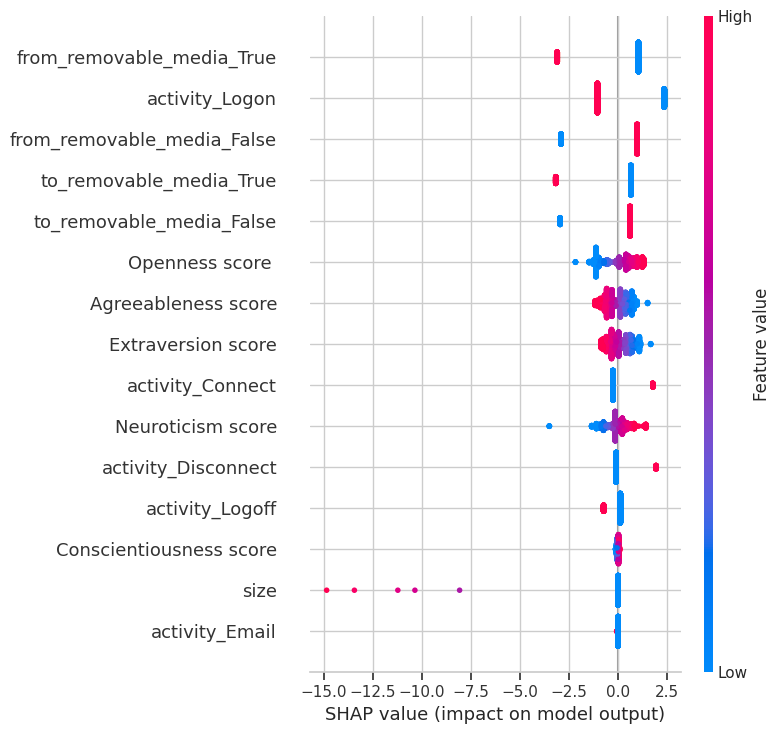

In [51]:
# ===========================================================================
# SHAP summary – Logistic Regression (GLM)
# For GLM, it use LinearExplainer, which is designed for linear models.
# ===========================================================================
glm_model_only = glm_clf.named_steps["model"]
explainer_glm = shap.LinearExplainer(glm_model_only, X_train_dense)
shap_values_glm = explainer_glm.shap_values(X_test_dense)
shap.summary_plot(
    shap_values_glm,
    X_test_dense,
    feature_names=all_feature_names
)

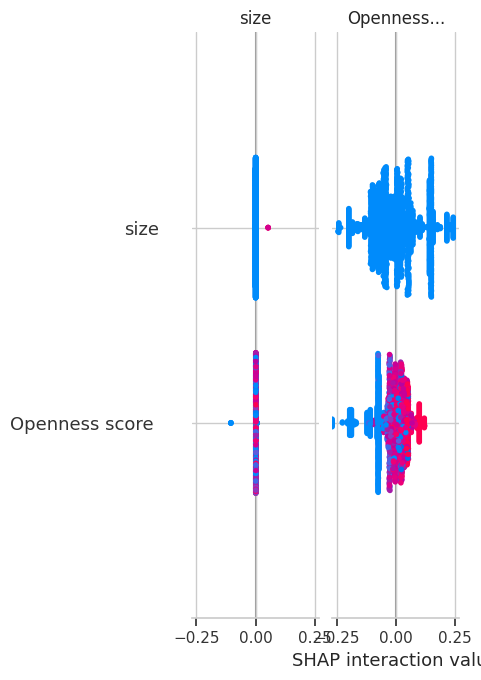

In [52]:
# ===========================================
# SHAP summary – Random Forest (tuned)
# ===========================================

rf_model_only = rf_best.named_steps["model"]
explainer_rf = shap.TreeExplainer(rf_model_only)
shap_values_rf = explainer_rf.shap_values(X_test_dense)

# For binary classification, TreeExplainer may return a list.
# take SHAP values for the positive class (Insider = 1).
if isinstance(shap_values_rf, list):
    shap_values_rf_to_plot = shap_values_rf[1]
else:
    shap_values_rf_to_plot = shap_values_rf

shap.summary_plot(
    shap_values_rf_to_plot,
    X_test_dense,
    feature_names=all_feature_names
)




---



#### 20. Final Comparison Table & Heatmap

Insider Threat – Model Benchmark (sorted by F1)


,accuracy,classification_error,AUC,precision,recall,F1
DT,0.9983,0.0017,0.9983,0.9967,1.0000,0.9983
RF,0.9967,0.0033,1.0000,0.9934,1.0000,0.9967
GBT (tuned),0.9967,0.0033,0.9997,0.9934,1.0000,0.9967
GBT,0.9967,0.0033,1.0000,0.9934,1.0000,0.9967
RF (tuned),0.9967,0.0033,1.0000,0.9934,1.0000,0.9967
DL,0.9925,0.0075,0.9989,0.9868,0.9983,0.9925
SVM,0.9846,0.0154,0.9964,0.9724,0.9975,0.9848
GLM (Logit),0.9546,0.0454,0.9911,0.9389,0.9725,0.9554
FLM (LDA),0.9396,0.0604,0.9907,0.8922,1.0000,0.9430
NB,0.9396,0.0604,0.9396,0.8922,1.0000,0.9430


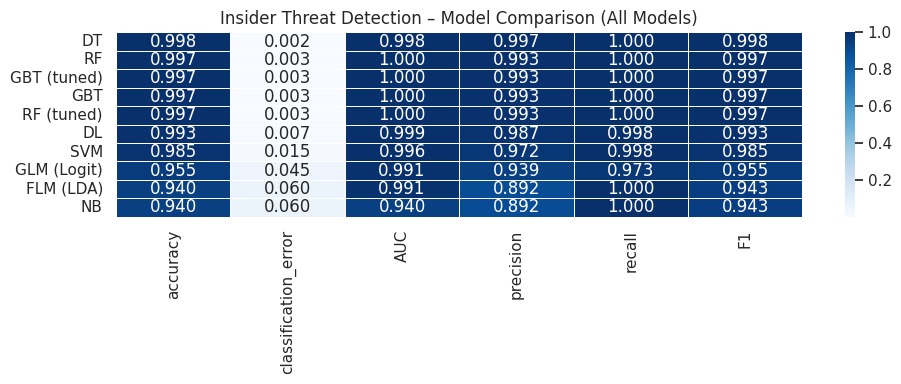

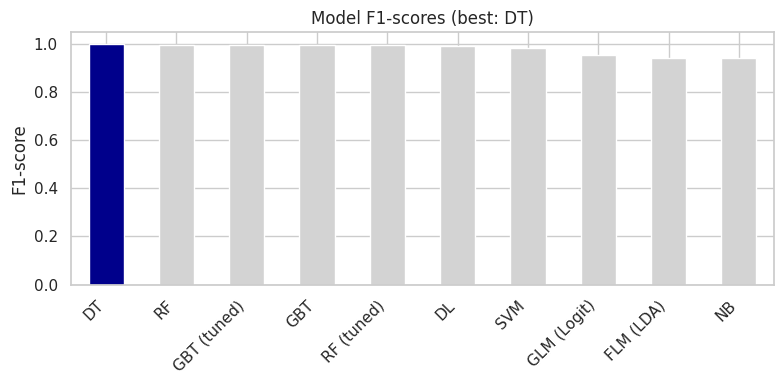

In [53]:
# ======================================================
# Final model comparison table + visualisations
# ======================================================

df_results = pd.DataFrame(results).T
df_results = df_results[[
    "accuracy", "classification_error",
    "AUC", "precision", "recall", "F1"
]].round(4)

# Sort by F1 (best at top)
df_results_sorted = df_results.sort_values("F1", ascending=False)

print("Insider Threat – Model Benchmark (sorted by F1)")
display(df_results_sorted)

# Heatmap of metrics
plt.figure(figsize=(10, 4))
sns.heatmap(
    df_results_sorted.astype(float),
    annot=True, fmt=".3f",
    cmap="Blues",
    cbar=True,
    linewidths=.5
)
plt.title("Insider Threat Detection – Model Comparison (All Models)")
plt.tight_layout()
plt.show()

# Bar chart for F1 with best model highlighted
best_model = df_results_sorted["F1"].idxmax()
colors = ["lightgrey"] * len(df_results_sorted)
best_idx = list(df_results_sorted.index).index(best_model)
colors[best_idx] = "darkblue"

plt.figure(figsize=(8,4))
df_results_sorted["F1"].plot(kind="bar", color=colors)
plt.title(f"Model F1-scores (best: {best_model})")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [54]:
# ===========================================
# Summary Printout
# ===========================================
best_f1_model = df_results_sorted["F1"].idxmax()
best_auc_model = df_results_sorted["AUC"].idxmax()

print("Best model by F1:", best_f1_model,
      "with F1 =", df_results_sorted.loc[best_f1_model, "F1"])
print("Best model by AUC:", best_auc_model,
      "with AUC =", df_results_sorted.loc[best_auc_model, "AUC"])


Best model by F1: DT with F1 = 0.9983
Best model by AUC: RF with AUC = 1.0




---

